## Support Vector Classifier Implementation

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
## Lets create synthetic data points
from sklearn.datasets import make_classification

In [9]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,
                        n_clusters_per_class=2,n_redundant=0)  

In [10]:
X

array([[ 0.95474839,  0.94348784],
       [ 0.97814866, -0.74363041],
       [ 1.21325752,  0.9739437 ],
       ...,
       [-0.33347925,  1.78696054],
       [ 0.38534264, -1.76550738],
       [-3.37808495, -0.09361743]], shape=(1000, 2))

In [11]:
pd.DataFrame(X)[0]

0      0.954748
1      0.978149
2      1.213258
3      1.308048
4     -1.266024
         ...   
995   -1.069310
996    0.501074
997   -0.333479
998    0.385343
999   -3.378085
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

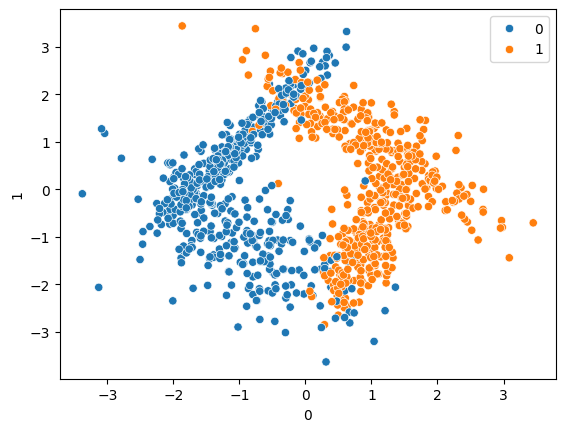

In [12]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1],hue=y)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [14]:
from sklearn.svm import SVC

In [15]:
svc=SVC(kernel='linear')

In [16]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [17]:
svc.coef_

array([[2.23028314, 0.17270363]])

In [18]:
## Prediction
y_pred=svc.predict(X_test)

In [19]:
from sklearn.metrics import classification_report,confusion_matrix

In [20]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93       121
           1       0.94      0.92      0.93       129

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250

[[113   8]
 [ 10 119]]


In [21]:
rbf=SVC(kernel='rbf')

In [22]:
rbf.fit(X_train,y_train)

SVC()

In [23]:
## Prediction
y_pred1=rbf.predict(X_test)

In [24]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       121
           1       0.96      0.95      0.95       129

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

[[116   5]
 [  7 122]]


In [25]:
polynomial=SVC(kernel='poly')
polynomial.fit(X_train,y_train)
## Prediction
y_pred2=polynomial.predict(X_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       121
           1       0.93      0.92      0.93       129

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[112   9]
 [ 10 119]]


In [26]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
## Prediction
y_pred3=sigmoid.predict(X_test)
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       121
           1       0.82      0.84      0.83       129

    accuracy                           0.82       250
   macro avg       0.82      0.82      0.82       250
weighted avg       0.82      0.82      0.82       250

[[ 98  23]
 [ 21 108]]


In [27]:
sigmoid.intercept_

array([-0.15515612])

## Hyperparametere Tuning With SVC

In [28]:
from sklearn.model_selection import GridSearchCV
 
# defining parameter range
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001, 'scale', 'auto'], # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'], # Different kernel types
}

In [29]:
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)

In [30]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.907 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.913 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.920 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.880 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.887 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.907 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=pol

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 'scale', 'auto'],
                         'kernel': ['rbf', 'linear', 'poly', 'sigmoid']},
             verbose=3)

In [31]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [32]:
## Prediction
y_pred_grid=grid.predict(X_test)
print(classification_report(y_test,y_pred_grid))
print(confusion_matrix(y_test,y_pred_grid))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       121
           1       0.97      0.96      0.96       129

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250

[[117   4]
 [  5 124]]
